# 6 — ControlNet: valutazione quantitativa

La generazione condizionata si valuta su **due assi**:

- **DSC** — aderenza alla maschera: quanto il volume generato rispetta la segmentazione imposta.
- **FID / MMD / MS-SSIM** — realismo e diversita', le stesse metriche usate per l'LDM
  incondizionato (notebook 4). Un modello potrebbe rispettare la maschera generando immagini
  brutte: le due famiglie di metriche sono complementari.

Protocollo del DSC, per ogni volume: la maschera reale condiziona la generazione, il volume
generato viene ri-segmentato con FSL-FAST, si calcola il Dice fra maschera richiesta e ottenuta.

Il checkpoint e' scelto per DSC sul **validation**; i parametri di inferenza sono ottimizzati
su un sottoinsieme del validation; il **test** e' usato solo per i numeri finali.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

METRICS="../outputs/metrics"

def load_json(name):
    with open(f"{METRICS}/{name}.json") as f:
        return json.load(f)

#selezione del checkpoint (inferenza standard, cond_scale=1.0)
val={e:load_json(f"dsc_val_epoch{e}") for e in (60,80,100)}
#configurazione finale
val_fin=load_json("dsc_val_v_final")
test_fin=load_json("dsc_test_v_final")
test_v6=load_json("dsc_test_epoch100")
tetto=load_json("dsc_tetto_clean")

print(f"selezione checkpoint : {[(e, round(d['mean_dsc'],4)) for e,d in val.items()]}")
print(f"v6  test  (baseline) : {test_v6['mean_dsc']:.4f}")
print(f"v_final validation   : {val_fin['mean_dsc']:.4f}")
print(f"v_final test         : {test_fin['mean_dsc']:.4f}")
print(f"tetto della pipeline : {tetto['mean_dsc']:.4f}")

selezione checkpoint : [(60, 0.6523), (80, 0.6747), (100, 0.6774)]
v6  test  (baseline) : 0.6776
v_final validation   : 0.7338
v_final test         : 0.7328
tetto della pipeline : 0.7875


## Il tetto della misura

Prima di leggere qualunque DSC serve sapere **qual e' il massimo ottenibile**. Le due
maschere confrontate non nascono allo stesso modo: quella di condizionamento viene da FAST
sul volume **raw**, quella del generato da FAST su un volume **decodificato dal VAE**, che
ha perso dettaglio attraverso il collo di bottiglia `4 x 64^3`.

Per quantificare questo scarto si prendono volumi **reali**, li si decodifica e ri-segmenta
lungo lo stesso percorso dei sintetici, e si confronta il risultato con la loro maschera di
condizionamento. Essendo lo stesso cervello, un DSC inferiore a 1 misura solo la perdita
introdotta dalla pipeline: e' il **tetto**, non superabile da nessun modello generativo.

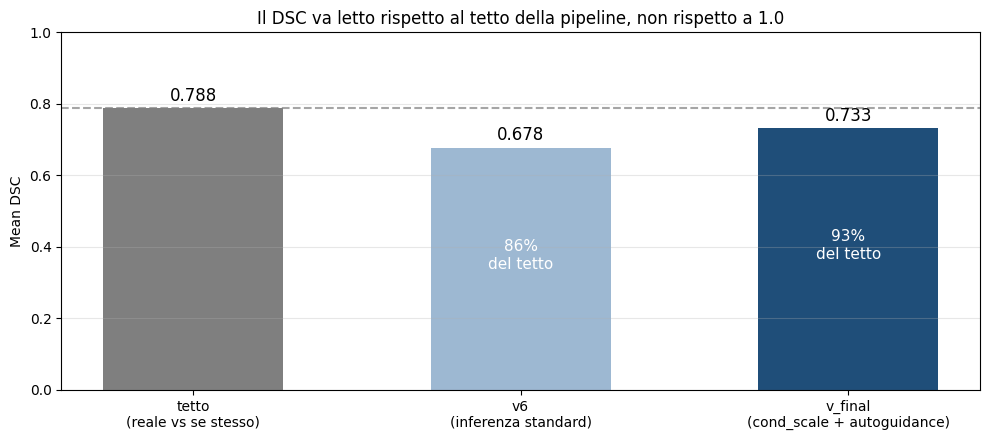

In [2]:
fig, ax=plt.subplots(figsize=(10,4.5))
labels=["tetto\n(reale vs se stesso)", "v6\n(inferenza standard)", "v_final\n(cond_scale + autoguidance)"]
vals=[tetto["mean_dsc"], test_v6["mean_dsc"], test_fin["mean_dsc"]]
colors=["#7f7f7f","#9db8d2","#1f4e79"]
bars=ax.bar(labels, vals, color=colors, width=0.55)
ax.axhline(tetto["mean_dsc"], ls="--", color="#7f7f7f", alpha=0.7)
ax.set_ylim(0,1.0); ax.set_ylabel("Mean DSC")
ax.set_title("Il DSC va letto rispetto al tetto della pipeline, non rispetto a 1.0")
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}", ha="center", fontsize=12)
for b,v in list(zip(bars,vals))[1:]:
    ax.text(b.get_x()+b.get_width()/2, v/2, f"{100*v/tetto['mean_dsc']:.0f}%\ndel tetto",
            ha="center", color="white", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Selezione del checkpoint (validation)

Tre checkpoint candidati, valutati per DSC sulle 100 maschere di validation. Il test non
viene toccato in questa fase.

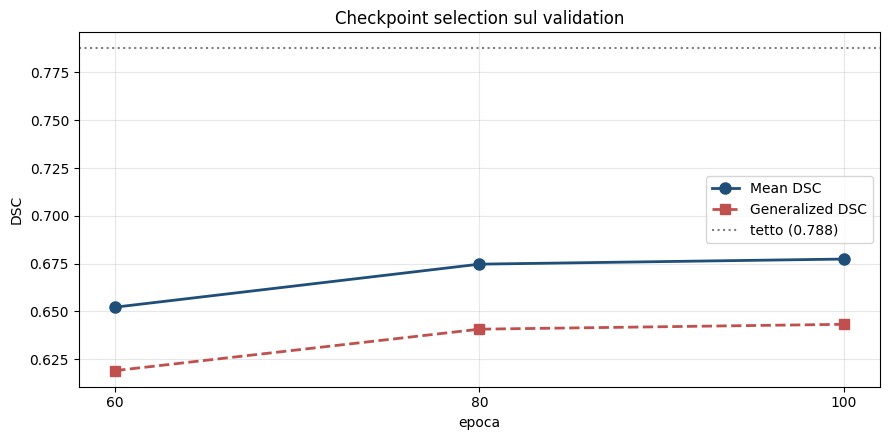

epoca   mean DSC    gen DSC     std     
60      0.6523      0.6191      0.0229  
80      0.6747      0.6408      0.0228  
100     0.6774      0.6433      0.0227  

selezionato: epoch100


In [3]:
epochs=[60,80,100]
means=[val[e]["mean_dsc"] for e in epochs]
gens=[val[e]["generalized_dsc"] for e in epochs]

fig, ax=plt.subplots(figsize=(9,4.5))
ax.plot(epochs, means, "o-", label="Mean DSC", color="#1f4e79", lw=2, ms=8)
ax.plot(epochs, gens, "s--", label="Generalized DSC", color="#c0504d", lw=2, ms=7)
ax.axhline(tetto["mean_dsc"], ls=":", color="#7f7f7f", label=f"tetto ({tetto['mean_dsc']:.3f})")
ax.set_xlabel("epoca"); ax.set_ylabel("DSC"); ax.set_xticks(epochs)
ax.set_title("Checkpoint selection sul validation")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'epoca':<8}{'mean DSC':<12}{'gen DSC':<12}{'std':<8}")
for e in epochs:
    d=val[e]
    print(f"{e:<8}{d['mean_dsc']:<12.4f}{d['generalized_dsc']:<12.4f}{d['per_volume_std']:<8.4f}")
print("\nselezionato: epoch100")

## Ottimizzazione dell'inferenza

Scelto il checkpoint, i parametri di generazione sono stati ottimizzati **senza riaddestrare
nulla**, su un sottoinsieme di 25 maschere del validation (le stesse per ogni configurazione,
generazione deterministica: le differenze osservate dipendono solo dal parametro variato).

### Conditioning scale

I residui prodotti dalla ControlNet vengono moltiplicati per un fattore prima di essere iniettati
nella UNet congelata: valori maggiori di 1 rafforzano l'aderenza alla maschera.

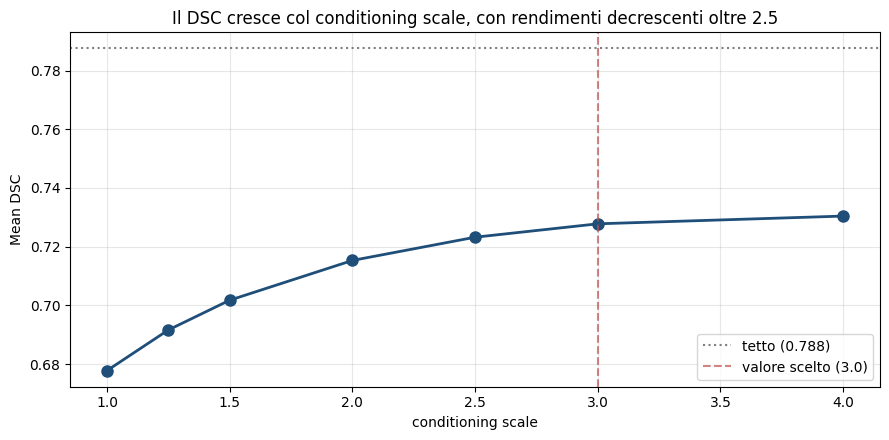

cond_scale   mean DSC    guadagno  
1.0          0.6778      -         
1.25         0.6916      +0.0138   
1.5          0.7018      +0.0101   
2.0          0.7153      +0.0135   
2.5          0.7232      +0.0079   
3.0          0.7278      +0.0046   
4.0          0.7304      +0.0026   


In [4]:
cs_vals=["1.0","1.25","1.5","2.0","2.5","3.0","4.0"]
cs_dsc=[]
for cs in cs_vals:
    try: cs_dsc.append(load_json(f"dsc_sweep_cs{cs}")["mean_dsc"])
    except FileNotFoundError: cs_dsc.append(np.nan)

fig, ax=plt.subplots(figsize=(9,4.5))
ax.plot([float(x) for x in cs_vals], cs_dsc, "o-", color="#1f4e79", lw=2, ms=8)
ax.axhline(tetto["mean_dsc"], ls=":", color="#7f7f7f", label=f"tetto ({tetto['mean_dsc']:.3f})")
ax.axvline(3.0, ls="--", color="#c0504d", alpha=0.7, label="valore scelto (3.0)")
ax.set_xlabel("conditioning scale"); ax.set_ylabel("Mean DSC")
ax.set_title("Il DSC cresce col conditioning scale, con rendimenti decrescenti oltre 2.5")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'cond_scale':<13}{'mean DSC':<12}{'guadagno':<10}")
prev=None
for cs,d in zip(cs_vals, cs_dsc):
    g=f"{d-prev:+.4f}" if prev is not None else "-"
    print(f"{cs:<13}{d:<12.4f}{g:<10}")
    prev=d

### Schedule del conditioning scale (esperimento negativo)

Alcuni lavori riportano che il controllo spaziale agisce prevalentemente nei **primi** passi del
denoising, quando si fissa la struttura. Si e' quindi testato un fattore variabile lungo il
denoising, a parita' di valore medio (2.5):

- **decrescente** 4.0 -> 1.0 (forte all'inizio, debole alla fine)
- **crescente** 1.0 -> 4.0 (l'opposto)

Nessuna delle due supera il fattore costante: conta l'intensita' media, non la sua distribuzione
temporale. L'osservazione riportata in letteratura per il controllo di *layout* in 2D non si
trasferisce alla segmentazione tissutale al voxel.

In [5]:
sched=[("costante 2.5","dsc_sweep_cs2.5"),
       ("crescente 1.0->4.0","dsc_sweep_schedB"),
       ("decrescente 4.0->1.0","dsc_sweep_schedA")]
print(f"{'schedule (media 2.5)':<24}{'mean DSC':<12}")
print("-"*36)
for nome,tag in sched:
    try: print(f"{nome:<24}{load_json(tag)['mean_dsc']:<12.4f}")
    except FileNotFoundError: print(f"{nome:<24}(mancante)")

schedule (media 2.5)    mean DSC    
------------------------------------
costante 2.5            0.7232      
crescente 1.0->4.0      0.7231      
decrescente 4.0->1.0    0.7165      


### Autoguidance

Come per l'LDM incondizionato, la predizione viene estrapolata fra il modello finale e uno
precoce dello stesso run: `v = v_bad + w*(v_good - v_bad)`, con `bad = epoch 200`. I residui
della ControlNet sono iniettati **identici** in entrambe le UNet, cosi' la differenza fra le due
predizioni isola la qualita' del denoising senza toccare il condizionamento.

L'autoguidance nasce per migliorare la qualita' *senza* agire sull'aderenza al condizionamento;
qui migliora anche il DSC, verosimilmente perche' confini piu' netti vengono ri-segmentati con
maggiore precisione.

In [6]:
ag=[("nessuna","dsc_sweep_cs3.0_bis"),("w=1.5","dsc_sweep_ag_w1.5"),
    ("w=2.0","dsc_sweep_ag_cs3.0"),("w=3.0","dsc_sweep_ag_w3.0")]
print(f"{'autoguidance':<16}{'mean DSC':<12}{'std':<10}")
print("-"*38)
for nome,tag in ag:
    try:
        d=load_json(tag)
        print(f"{nome:<16}{d['mean_dsc']:<12.4f}{d['per_volume_std']:<10.4f}")
    except FileNotFoundError: print(f"{nome:<16}(mancante)")
print("\nscelto w=2.0: w=3.0 guadagna poco (+0.004) ma aumenta la dispersione,")
print("e 2.0 e' lo stesso valore usato per l'LDM incondizionato (coerenza fra i due stadi).")

autoguidance    mean DSC    std       
--------------------------------------
nessuna         (mancante)
w=1.5           0.7325      0.0143    
w=2.0           0.7328      0.0144    
w=3.0           0.7367      0.0160    

scelto w=2.0: w=3.0 guadagna poco (+0.004) ma aumenta la dispersione,
e 2.0 e' lo stesso valore usato per l'LDM incondizionato (coerenza fra i due stadi).


## Risultato finale sul test

La configurazione scelta — conditioning scale 3.0 e autoguidance w=2.0 — viene applicata una
volta sola alle 102 maschere di test.

In [7]:
rows=[
    ("v6  test (inferenza standard)", test_v6),
    ("v_final validation", val_fin),
    ("v_final test (finale)", test_fin),
    ("tetto della misura", tetto),
]
print(f"{'':<32}{'n':>5}{'mean DSC':>11}{'gen DSC':>10}{'std':>8}{'% tetto':>10}")
print("-"*76)
for name,d in rows:
    pct=100*d["mean_dsc"]/tetto["mean_dsc"]
    print(f"{name:<32}{d['n_pairs']:>5}{d['mean_dsc']:>11.4f}{d['generalized_dsc']:>10.4f}"
          f"{d['per_volume_std']:>8.4f}{pct:>9.0f}%")

print(f"\nscarto validation-test : {abs(val_fin['mean_dsc']-test_fin['mean_dsc']):.4f}")
print(f"guadagno v6 -> v_final : {test_fin['mean_dsc']-test_v6['mean_dsc']:+.4f} "
      f"({100*test_v6['mean_dsc']/tetto['mean_dsc']:.0f}% -> {100*test_fin['mean_dsc']/tetto['mean_dsc']:.0f}% del tetto)")

                                    n   mean DSC   gen DSC     std   % tetto
----------------------------------------------------------------------------
v6  test (inferenza standard)     102     0.6776    0.6407  0.0254       86%
v_final validation                100     0.7338    0.6993  0.0196       93%
v_final test (finale)             102     0.7328    0.6955  0.0207       93%
tetto della misura                 10     0.7875    0.7473  0.0201      100%

scarto validation-test : 0.0010
guadagno v6 -> v_final : +0.0552 (86% -> 93% del tetto)


**Validation e test coincidono a 0.001**, come gia' per il v6: l'ottimizzazione dei parametri
di inferenza sul sottoinsieme di validation non ha sovradattato. Il guadagno di **+0.055**
rispetto all'inferenza standard e' ottenuto **senza alcun riaddestramento**.

## Distribuzione per volume

La media non basta: interessa sapere se il risultato e' uniforme o se dipende da pochi casi
fortunati. Una distribuzione stretta indica un condizionamento affidabile su tutti i soggetti.

/tmp/ipykernel_1289448/1437181260.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([scores_v6, scores], labels=["v6","v_final"])


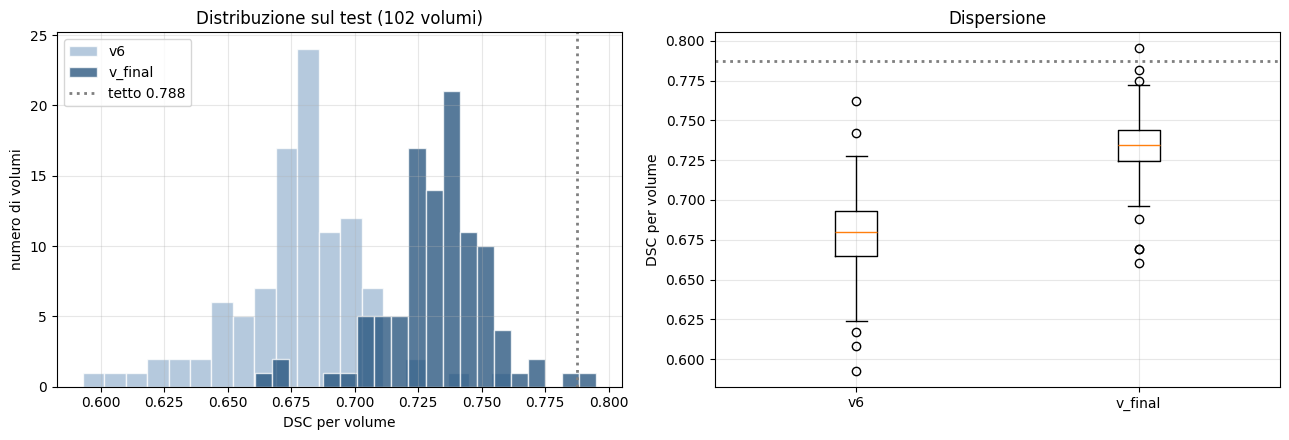

v6      : min 0.5929 | max 0.7620 | std 0.0254
v_final : min 0.6606 | max 0.7951 | std 0.0207


In [8]:
scores=np.array(list(test_fin["per_volume"].values()))
scores_v6=np.array(list(test_v6["per_volume"].values()))

fig, axes=plt.subplots(1, 2, figsize=(13,4.5))
axes[0].hist(scores_v6, bins=20, color="#9db8d2", alpha=0.75, edgecolor="white", label="v6")
axes[0].hist(scores, bins=20, color="#1f4e79", alpha=0.75, edgecolor="white", label="v_final")
axes[0].axvline(tetto["mean_dsc"], color="#7f7f7f", ls=":", lw=2, label=f"tetto {tetto['mean_dsc']:.3f}")
axes[0].set_xlabel("DSC per volume"); axes[0].set_ylabel("numero di volumi")
axes[0].set_title("Distribuzione sul test (102 volumi)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].boxplot([scores_v6, scores], labels=["v6","v_final"])
axes[1].axhline(tetto["mean_dsc"], color="#7f7f7f", ls=":", lw=2)
axes[1].set_ylabel("DSC per volume"); axes[1].set_title("Dispersione")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"v6      : min {scores_v6.min():.4f} | max {scores_v6.max():.4f} | std {scores_v6.std():.4f}")
print(f"v_final : min {scores.min():.4f} | max {scores.max():.4f} | std {scores.std():.4f}")

## Caso migliore e caso peggiore

Confronto visivo tra il volume col DSC piu' alto e quello col DSC piu' basso: mostra
concretamente cosa distingue un condizionamento riuscito da uno meno preciso.

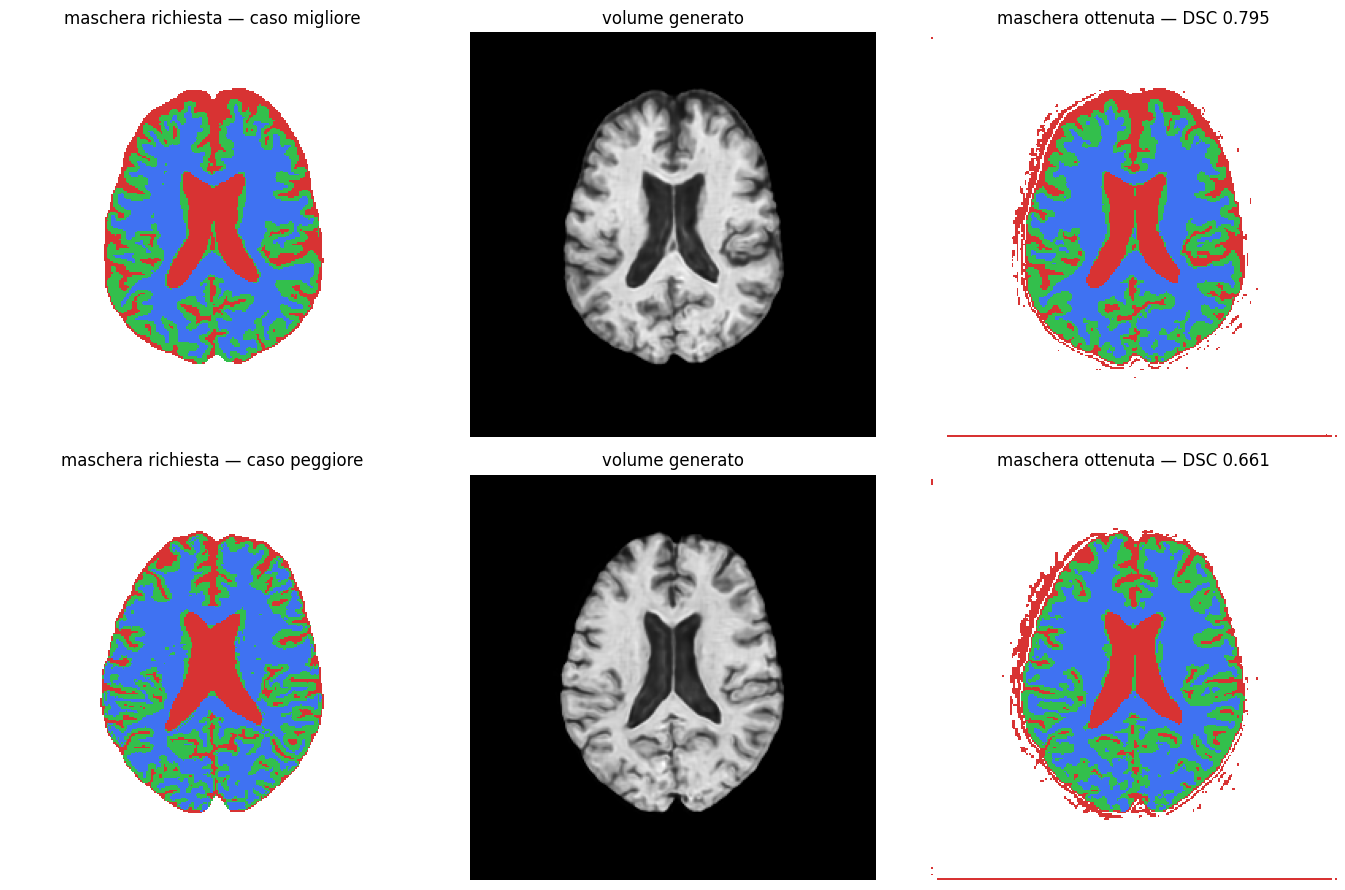

migliore: 0.7951
peggiore: 0.6606


In [9]:
import nibabel as nib
from matplotlib.colors import ListedColormap

GEN_DIR="../data/controlnet_gen_test/v_final"
TISSUE_CMAP=ListedColormap([(0,0,0,0),(0.85,0.20,0.20,1),(0.20,0.75,0.30,1),(0.25,0.45,0.95,1)])

pv=test_fin["per_volume"]
best=max(pv, key=pv.get); worst=min(pv, key=pv.get)

def load(p): return np.asarray(nib.load(p).dataobj).astype(np.float32)

fig, axes=plt.subplots(2, 3, figsize=(14,9))
for r,(base,tag) in enumerate([(best,"migliore"),(worst,"peggiore")]):
    cond=np.rot90(load(f"{GEN_DIR}/{base}_condmask.nii.gz")[:,:,128])
    seg=np.rot90(load(f"{GEN_DIR}/{base}_synth_pveseg.nii.gz")[:,:,128])
    synth=np.rot90(load(f"{GEN_DIR}/{base}_synth.nii.gz")[:,:,128])
    axes[r,0].imshow(cond, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
    axes[r,0].set_title(f"maschera richiesta — caso {tag}")
    axes[r,1].imshow(synth, cmap="gray"); axes[r,1].set_title("volume generato")
    axes[r,2].imshow(seg, cmap=TISSUE_CMAP, vmin=0, vmax=3, interpolation="nearest")
    axes[r,2].set_title(f"maschera ottenuta — DSC {pv[base]:.3f}")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

print(f"migliore: {pv[best]:.4f}\npeggiore: {pv[worst]:.4f}")

## Controllo geometrico

Lo stesso test usato per l'LDM incondizionato (`tests/check_degenerate_samples.py`) verifica che
i volumi generati non siano fuori posizione: centroide, estensione e frazione di tessuto vengono
confrontati con la distribuzione dei reali. Il controllo e' in parte ridondante — un volume
traslato avrebbe un DSC prossimo a zero — ma conferma in modo indipendente che il condizionamento
vincola anche la collocazione globale.

volumi analizzati        : 102
traslati oltre 5 voxel   : 0 (0%)
spostamento massimo      : 3.4 voxel
frazione tessuto (sint.) : mediana 0.1102  [0.1024-0.1171]
frazione tessuto (reali) : mediana 0.1102


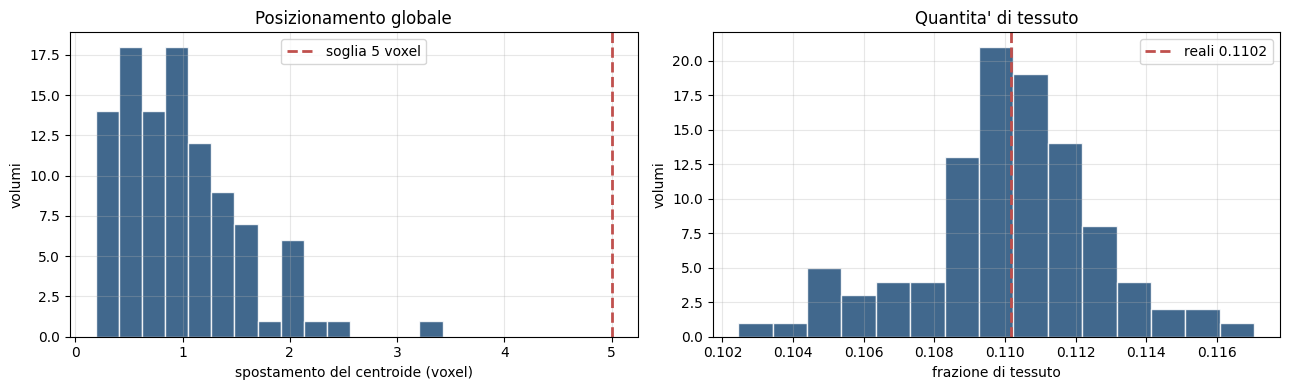

In [10]:
qc=load_json("degenerate_v_final")
ref={k:v["median"] for k,v in qc["reference_median_mad"].items()}
shift=np.array([max(abs(x[k]-ref[k])*256 for k in ("cx","cy","cz") if x[k] is not None)
                for x in qc["samples"]])
frac=np.array([x["frac"] for x in qc["samples"] if x["frac"] is not None])

print(f"volumi analizzati        : {len(shift)}")
print(f"traslati oltre 5 voxel   : {(shift>5).sum()} ({100*(shift>5).mean():.0f}%)")
print(f"spostamento massimo      : {shift.max():.1f} voxel")
print(f"frazione tessuto (sint.) : mediana {np.median(frac):.4f}  [{frac.min():.4f}-{frac.max():.4f}]")
print(f"frazione tessuto (reali) : mediana {ref['frac']:.4f}")

fig, axes=plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(shift, bins=15, color="#1f4e79", alpha=0.85, edgecolor="white")
axes[0].axvline(5, color="#c0504d", ls="--", lw=2, label="soglia 5 voxel")
axes[0].set_xlabel("spostamento del centroide (voxel)"); axes[0].set_ylabel("volumi")
axes[0].set_title("Posizionamento globale"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(frac, bins=15, color="#1f4e79", alpha=0.85, edgecolor="white")
axes[1].axvline(ref["frac"], color="#c0504d", ls="--", lw=2, label=f"reali {ref['frac']:.4f}")
axes[1].set_xlabel("frazione di tessuto"); axes[1].set_ylabel("volumi")
axes[1].set_title("Quantita' di tessuto"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Realismo e diversita'

Il DSC misura l'aderenza alla maschera, non la qualita' dell'immagine: un modello potrebbe
rispettare la segmentazione producendo volumi poco realistici. Si calcolano quindi le stesse
metriche del notebook 4 — **FID 2.5D**, **MMD**, **MS-SSIM** — confrontando i 102 volumi
condizionati con i 102 reali di test.

I volumi generati sono salvati nel loro range nativo (necessario per la segmentazione FSL-FAST);
per il confronto vengono riportati in `[0,1]` col 99.5 percentile, lo stesso usato sui reali dal
preprocessing di encoding.

                             LDM (incond.)    ControlNet
--------------------------------------------------------
FID medio                            24.31         22.55
  FID XY                             25.50         21.72
  FID YZ                             27.26         23.33
  FID ZX                             20.17         22.60
MMD                                 0.0089        0.0085
MS-SSIM sintetiche                  0.9486        0.9385
MS-SSIM reali                       0.9357        0.9357


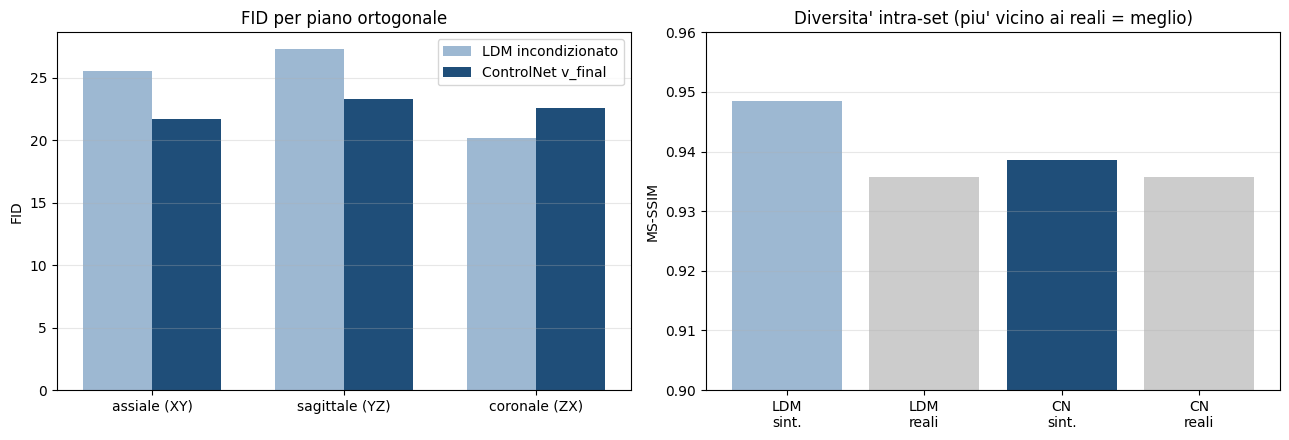

In [11]:
ev_cn=load_json("eval_test_controlnet_v_final")
ev_ldm=load_json("eval_test_v5")   # LDM incondizionato, notebook 4

print(f"{'':<26}{'LDM (incond.)':>16}{'ControlNet':>14}")
print("-"*56)
for k,nome in [("fid_avg","FID medio"),("fid_xy","  FID XY"),("fid_yz","  FID YZ"),
               ("fid_zx","  FID ZX"),("mmd","MMD"),
               ("msssim_synth","MS-SSIM sintetiche"),("msssim_real","MS-SSIM reali")]:
    a=ev_ldm.get(k); b=ev_cn.get(k)
    fa=f"{a:.4f}" if k.startswith(("mmd","msssim")) else f"{a:.2f}"
    fb=f"{b:.4f}" if k.startswith(("mmd","msssim")) else f"{b:.2f}"
    print(f"{nome:<26}{fa:>16}{fb:>14}")

fig, axes=plt.subplots(1, 2, figsize=(13,4.5))
piani=["fid_xy","fid_yz","fid_zx"]
x=np.arange(3); w=0.36
axes[0].bar(x-w/2, [ev_ldm[p] for p in piani], w, label="LDM incondizionato", color="#9db8d2")
axes[0].bar(x+w/2, [ev_cn[p] for p in piani], w, label="ControlNet v_final", color="#1f4e79")
axes[0].set_xticks(x); axes[0].set_xticklabels(["assiale (XY)","sagittale (YZ)","coronale (ZX)"])
axes[0].set_ylabel("FID"); axes[0].set_title("FID per piano ortogonale")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(["LDM\nsint.","LDM\nreali","CN\nsint.","CN\nreali"],
            [ev_ldm["msssim_synth"],ev_ldm["msssim_real"],
             ev_cn["msssim_synth"],ev_cn["msssim_real"]],
            color=["#9db8d2","#cccccc","#1f4e79","#cccccc"])
axes[1].set_ylim(0.90,0.96); axes[1].set_ylabel("MS-SSIM")
axes[1].set_title("Diversita' intra-set (piu' vicino ai reali = meglio)")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Lettura dei risultati

**Aderenza al condizionamento.** DSC finale sul test **0.733** (generalizzato 0.696), su 102
volumi hold-out, con deviazione standard 0.021 e nessun caso degenere. Rispetto al tetto della
pipeline (0.788) la ControlNet raggiunge il **93% del massimo ottenibile**; il 21% che separa il
tetto dall'unita' non dipende dal condizionamento ma dalla struttura della valutazione (la
compressione del VAE e il confronto fra maschere prodotte lungo percorsi diversi).

**Effetto dell'ottimizzazione dell'inferenza.** Conditioning scale e autoguidance, applicati
senza riaddestrare nulla, portano il DSC da 0.678 a 0.733 (**+0.055**, dall'86% al 93% del
tetto) e riducono anche la dispersione fra volumi. Lo schedule temporale del conditioning scale,
testato in entrambe le direzioni, non migliora il fattore costante: conta l'intensita' media.

**Realismo.** Il FID dei volumi condizionati (**22.55**) e' migliore di quello della generazione
incondizionata (24.31), e i tre piani ortogonali sono molto piu' uniformi (21.7-23.3 contro
20.2-27.3): vincolando l'anatomia, la capacita' generativa si concentra sulla texture invece che
sulla struttura globale. Il divario sagittale, limite ricorrente dell'LDM in tutte le versioni,
si riduce nettamente.

**Diversita'.** MS-SSIM delle sintetiche **0.9385** contro **0.9357** dei reali: scarto di 0.003,
contro lo 0.013 della generazione incondizionata. Il condizionamento non appiattisce la varieta'
anatomica.

**Geometria.** Nessun volume fuori posizione (0/102, spostamento massimo 3.4 voxel) e frazione di
tessuto identica ai reali (0.1102).

**Confrontabilita' con la letteratura.** Il DSC e' direttamente confrontabile perche' calcolato
con la stessa definizione; FID, MMD e MS-SSIM no, perche' dipendono dall'estrattore di feature
scelto (qui InceptionV3 2.5D) — vanno usati solo per confronti interni fra le configurazioni di
questo lavoro.